In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df=pd.read_pickle(f"../df.pkl")
y=df[['dm']]
X=df.drop(columns=['dm'])

In [11]:
X.min()

sex               1.000000
age              20.000000
edu               1.000000
income            1.000000
job               1.000000
glu              60.000000
hba1c             3.300000
chol             78.000000
hdl              16.000000
tg               18.000000
ldl              17.000000
sbp              76.500000
wt               27.500000
ht              130.700000
wc               51.100000
bmi              13.133958
wk_smk            0.000000
wk_alc            0.000000
wk_mvpa_play      0.000000
wk_walk          10.000000
wk_sleep         60.000000
stress            1.000000
wk_break          0.000000
wk_lunch          0.000000
wk_dinner         0.000000
wk_veg1           0.000000
wk_veg2           0.000000
wk_fruit          0.000000
dtype: float64

In [12]:
X.max()

sex                2.000000
age               80.000000
edu                4.000000
income             5.000000
job                7.000000
glu              377.000000
hba1c             13.100000
chol             489.000000
hdl              142.000000
tg              1816.000000
ldl              394.000000
sbp              204.000000
wt               147.000000
ht               194.000000
wc               138.500000
bmi               48.054904
wk_smk           420.000000
wk_alc            40.000000
wk_mvpa_play    1470.000000
wk_walk         3780.000000
wk_sleep        1260.000000
stress             4.000000
wk_break           6.000000
wk_lunch           6.000000
wk_dinner          6.000000
wk_veg1           21.000000
wk_veg2           21.000000
wk_fruit          21.000000
dtype: float64

In [4]:
import torch.cuda
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

True
NVIDIA GeForce RTX 4070 SUPER


In [13]:
import torch.nn as nn
import torch
from lightning.pytorch import LightningModule
from sklearn.metrics import classification_report, confusion_matrix


class MLPModel(nn.Module):
    def __init__(self,input_dim,inter_dim,dropout):
        super().__init__()
        #dim1=int(dim1)
        self.input_layer=nn.Sequential(
            nn.Linear(input_dim,64),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(64,32),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(32,16),
            nn.GELU(),
            nn.Dropout(dropout),            
        )
        self.output_layer=nn.Linear(16,inter_dim)

    def forward(self,x):
        x=self.input_layer(x)
        output=self.output_layer(x)
        return output


class LitModel(LightningModule):
    def __init__(self,  lr=1e-3,do=0.4, wd=1e-4):
        super().__init__()
        #dim1=int(dim1)
        self.save_hyperparameters()
        self.model = MLPModel(28,3,dropout=do)
        self.lr = lr
        self.wd=wd
        
        self.train_acc = []
        self.train_loss=[]
        self.valid_acc = []
        self.valid_loss=[]
        

    def forward(self, x):
        return self.model(x)
    
    def custom_loss(self,preds,targets):
        loss=nn.CrossEntropyLoss()        #HuberLoss: MSELoss, MAELoss의 단점을 보완하고 절충한 손실함수이다.
        final_loss=loss(preds,targets)
        return final_loss

    def training_step(self, batch,batch_idx):
        x, y = batch
        logits = self(x)    #forward 메서드 호출
        loss = self.custom_loss(logits, y.long())
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("train_loss", loss, on_epoch=True, on_step=False, prog_bar=True)
        self.log("train_acc", acc, on_epoch=True, on_step=False, prog_bar=True)
        return {"loss": loss, "train_acc": acc}

    def validation_step(self, batch,batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.custom_loss(logits, y.long())
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("val_loss", loss, on_epoch=True, on_step=False, prog_bar=True)
        self.log("val_acc", acc, on_epoch=True, on_step=False, prog_bar=True)
        return {"val_loss": loss, "val_acc": acc}

    def test_step(self, batch,batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.custom_loss(logits, y.long())
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("test_loss", loss, on_epoch=True, on_step=False, prog_bar=True)
        self.log("test_acc", acc, on_epoch=True, on_step=False, prog_bar=True)
        self.y_preds.append(logits.argmax(dim=1).detach().cpu())
        self.y_trues.append(y.detach().cpu())
        return {"test_loss": loss, "test_acc": acc}

    def configure_optimizers(self):
        optimizer= torch.optim.AdamW(self.parameters(), lr=self.lr,weight_decay=self.wd)
        return optimizer
        
    def predict_step(self, batch, batch_idx):
        x, _ = batch  # 정답(y)는 필요 없으므로 무시
        logits = self.forward(x)           # 예측 (logits)
        preds = torch.argmax(logits, dim=1)  # 가장 높은 점수의 클래스 선택

        return preds  # shape: [B]
    
    def predict_proba(self, x):
        """x: tensor of shape [B, features]"""
        self.eval()
        with torch.no_grad():
            logits = self.model(x)           # (B, 3)
            probs = torch.softmax(logits, dim=1)
        return probs

        

    def on_test_start(self):       #테스트 시작 시 한번만 실행
        self.y_preds = []
        self.y_trues = []

    def on_test_end(self):               #테스트 종료 시 한번만 실행
        preds = torch.cat(self.y_preds)     
        trues = torch.cat(self.y_trues)
        print("\nTest Report:")
        print(classification_report(trues, preds))
        print("Confusion Matrix:")
        print(confusion_matrix(trues, preds))
        

In [14]:
import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader,Subset
from lightning.pytorch import LightningModule,Trainer
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from lightning.pytorch.loggers import CSVLogger
import ray
import os

from ray import tune
from ray.tune import RunConfig
from ray.tune import TuneConfig
from ray.air import session
from ray.tune.search.hyperopt import HyperOptSearch
from hyperopt import hp
import math


def to_tensor(*dfs):
    return [torch.tensor(df.values,dtype=torch.float32) for df in dfs]

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
acc_results = []
prec_results=[]
rec_results=[]
f1_results=[]

# Windows 환경에서 Ray dashboard 오류 방지
os.environ["RAY_DISABLE_DASHBOARD"] = "1"
os.environ["RAY_LOG_TO_STDERR"] = "1"

X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=0.2,
            random_state=42,
            shuffle=True
        )


def main():        
        
    model_paths=[]
    scalers=[]
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train)):
            
            print(f"\n Inner fold {fold + 1}")
            # Fold 별 subset 구성

            def make_trainable(train_subset, val_subset):
                def trainable(config):
                    train_loader = DataLoader(train_subset, batch_size=int(config["batchsize"]), shuffle=True)
                    val_loader = DataLoader(val_subset, batch_size=int(config["batchsize"]))
                    model = LitModel(lr=config["lr"],wd=config["wd"],do=config["do"])

                    ckpt_base_dir = "./ray_logs/checkpoints"
                    os.makedirs(ckpt_base_dir, exist_ok=True)
                    early_stop = EarlyStopping(monitor="val_acc", patience=100, mode="max")
                    checkpoint = ModelCheckpoint(monitor="val_acc", save_top_k=1, mode="max",dirpath=f"checkpoints/fold_{fold}", filename="best-checkpoint")

                    os.makedirs("./ray_logs", exist_ok=True)
                    log_base_dir = "./ray_logs/tune_logs"

                    os.makedirs(log_base_dir, exist_ok=True)

                    logger = CSVLogger(
                        save_dir="./ray_logs",  # 존재하는 경로로 지정
                        name="tune_logs",       # 폴더 이름
                        version=None            # 자동 버전 생성
                    )

                    trainer = Trainer(
                        accelerator="gpu",
                        devices=1,
                        max_epochs=400,
                        callbacks=[early_stop, checkpoint],
                        logger=logger,
                        enable_progress_bar=True
                        )

                    trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)
                    val_loss = trainer.callback_metrics.get("val_loss")
                    val_acc = trainer.callback_metrics.get("val_acc") 

                    if val_loss and val_acc is not None:
                        session.report({"val_loss": val_loss.item(),"val_acc":val_acc.item()})
                    else:
                        print("no saved values")
                return trainable
            
            X_tr_fold = X_train.iloc[train_idx]
            X_val_fold = X_train.iloc[val_idx]

            scaler = StandardScaler()
            X_tr_fold = scaler.fit_transform(X_tr_fold)
            X_val_fold = scaler.transform(X_val_fold)

            X_tr_fold = torch.tensor(X_tr_fold, dtype=torch.float32)
            X_val_fold = torch.tensor(X_val_fold, dtype=torch.float32)

            y_tr_fold = torch.tensor(
                y_train.iloc[train_idx].values.squeeze(),
                dtype=torch.long
            )

            y_val_fold = torch.tensor(
                y_train.iloc[val_idx].values.squeeze(),
                dtype=torch.long
            )

            train_subset = TensorDataset(X_tr_fold, y_tr_fold)
            val_subset = TensorDataset(X_val_fold, y_val_fold)


            tune_trainable=make_trainable(train_subset=train_subset,val_subset=val_subset)
            tune_trainable = tune.with_resources(tune_trainable, resources={"cpu": 14, "gpu": 1})
            # Ray Tune 실행
            param_space = {"lr": hp.loguniform("lr",-9.21, -4.61),"batchsize":hp.quniform("batchsize",32,256,1),"wd": hp.loguniform("wd",math.log(1e-6), math.log(1e-2)), "do":hp.loguniform("do",math.log(0.2), math.log(0.9))}

            hyperopt = HyperOptSearch(metric="val_acc", mode="max",space=param_space)
            def custom_trial_name(trial):
                return f"trial_{trial.trial_id}"

            tuner = tune.Tuner(
                    trainable=tune_trainable,
                    
                    tune_config=TuneConfig(
                        metric="val_acc",
                        mode="max",
                        num_samples=20, #default=30
                        search_alg=hyperopt,
                        trial_name_creator=custom_trial_name
                    ),
                    run_config=RunConfig(
                        name="hp_tuning",
                        storage_path="C:/ray_tmp",
                        log_to_file=False
                    )
                )

            results = tuner.fit()

                # 결과 출력 및 실패 trial 확인
            
            for i, result in enumerate(results):
                    print(f"\nTrial {i}")
                    if result.error:
                        print("Error:", result.error)
                    else:
                        print("acc:", result.metrics.get("val_acc"))   

            print("\n Best config:", results.get_best_result().config)

            #results에서 얻은 최적 하이퍼파라미터 이용 -> 모델 로드하기 
            best_config=results.get_best_result().config

            best_lr=best_config['lr']
            best_batch =int(best_config['batchsize'])
            best_wd=best_config["wd"]
            best_do=best_config["do"]


            #2. 최적 하이퍼파라미터 적용 모델에 대해 최적 파라미터 탐색
            # 모델 초기화
            train_loader = DataLoader(train_subset, batch_size=best_batch, shuffle=True)
            val_loader = DataLoader(val_subset, batch_size=best_batch)
            model = LitModel(lr=best_lr,wd=best_wd,do=best_do).to(device)
            
            #콜백 정의
            early_stop=EarlyStopping(monitor="val_acc",patience=100,mode="max")
            checkpoint=ModelCheckpoint(monitor="val_acc",mode="max",save_top_k=1,dirpath=f"final_checkpoints/fold_{fold}",filename="best-checkpoint")

            csv_logger = CSVLogger(save_dir="logs/", name="my_model",version=f"fold_{fold}")

            # Trainer 설정 (로그 저장 생략)
            trainer = Trainer(max_epochs=200, min_epochs=5,log_every_n_steps=1, callbacks=[early_stop,checkpoint],logger=csv_logger)
            trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

            best_model_path=checkpoint.best_model_path
            model_paths.append(best_model_path)
            scalers.append(scaler)

            #test 단계 추가
    
    return model_paths, scalers
    
if __name__ == "__main__":
    
    ray.shutdown()
    RAY_TMP_DIR = "C:\\temp\\ray_tmp" 
    os.makedirs(RAY_TMP_DIR, exist_ok=True)
    ray.init(_temp_dir=RAY_TMP_DIR,include_dashboard=False, logging_config=None)
    model_paths, scalers=main()

2026-06-22 16:15:25,861	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to 'C:/ray_tmp/hp_tuning' in 0.0325s.
2026-06-22 16:15:25,866	INFO tune.py:1041 -- Total run time: 1395.54 seconds (1395.48 seconds for the tuning loop).
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\cmc\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\fabric\loggers\csv_logs.py:268: Experiment logs directory logs/my_model\fold_4 exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
c:\Users\cmc\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:658: Checkpoint directory C:\Users\cmc\Desktop\T2D_AI_research\model\final_checkpoints\fold_4 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type     | Params | Mode 
---------------------------------


Trial 0
acc: 0.9625527262687683

Trial 1
acc: 0.9562236070632935

Trial 2
acc: 0.929852306842804

Trial 3
acc: 0.8744725584983826

Trial 4
acc: 0.9551687836647034

Trial 5
acc: 0.9609704613685608

Trial 6
acc: 0.9556962251663208

Trial 7
acc: 0.9614979028701782

Trial 8
acc: 0.9356539845466614

Trial 9
acc: 0.9588607549667358

Trial 10
acc: 0.9541139006614685

Trial 11
acc: 0.9251055121421814

Trial 12
acc: 0.9609704613685608

Trial 13
acc: 0.9541139006614685

Trial 14
acc: 0.9599156379699707

Trial 15
acc: 0.9562236070632935

Trial 16
acc: 0.8860759735107422

Trial 17
acc: 0.9261603951454163

Trial 18
acc: 0.9630801677703857

Trial 19
acc: 0.9599156379699707

 Best config: {'batchsize': 198.0, 'do': 0.6016929226022107, 'lr': 0.001224063528149332, 'wd': 6.249821982831234e-05}
                                                                            

c:\Users\cmc\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
c:\Users\cmc\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Epoch 199: 100%|██████████| 39/39 [00:00<00:00, 144.93it/s, v_num=ld_4, val_loss=0.110, val_acc=0.963, train_loss=0.215, train_acc=0.923]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 199: 100%|██████████| 39/39 [00:00<00:00, 142.29it/s, v_num=ld_4, val_loss=0.110, val_acc=0.963, train_loss=0.215, train_acc=0.923]


In [15]:
all_probs = []

for model_path, scaler in zip(model_paths, scalers):

    # 1. 모델 로드
    model = LitModel.load_from_checkpoint(model_path)
    model.to(device)
    model.eval()

    # 2. test scaling
    X_test_scaled = scaler.transform(X_test)

    # 3. tensor 변환
    X_test_tensor = torch.tensor(
        X_test_scaled,
        dtype=torch.float32
    ).to(device)

    # 4. prediction
    with torch.no_grad():

        logits = model(X_test_tensor)

        # softmax probability
        probs = torch.softmax(logits, dim=1)

        probs = probs.cpu().numpy()

    all_probs.append(probs)

# =========================
# 평균 probability
# =========================

mean_probs = np.mean(all_probs, axis=0)

# 최종 prediction
y_pred = np.argmax(mean_probs, axis=1)

# =========================
# metric 계산
# =========================

y_true = y_test.values.squeeze()

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="weighted")
rec = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 score : {f1:.4f}")

Accuracy : 0.9625
Precision: 0.9621
Recall   : 0.9625
F1 score : 0.9618


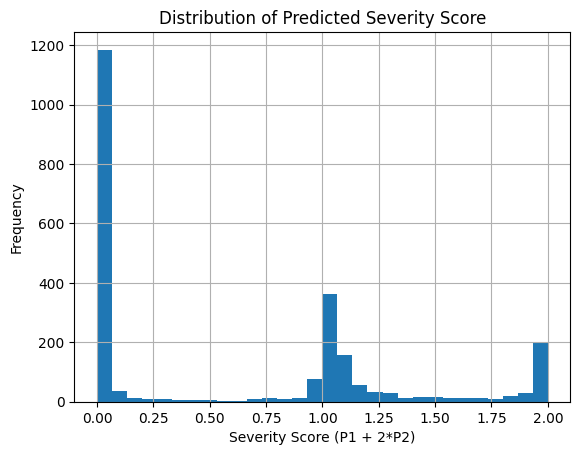

In [16]:
import matplotlib.pyplot as plt

y_score = mean_probs[:, 1] + 2 * mean_probs[:, 2]
y_score_series = pd.Series(y_score)

y_score_series.hist(bins=30)
plt.xlabel("Severity Score (P1 + 2*P2)")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted Severity Score")
plt.show()

In [17]:
import pickle

with open("../model_paths.pkl", "wb") as f:
    pickle.dump(model_paths, f)

with open("../scalers.pkl", "wb") as f:
    pickle.dump(scalers, f)